# Linear Difference Equations



In [ ]:
library(tidyverse)

Warning message:
“package ‘tidyverse’ was built under R version 4.4.3”
Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Warning message:
“package ‘tibble’ was built under R version 4.4.3”
Warning message:
“package ‘tidyr’ was built under R version 4.4.3”
Warning message:
“package ‘readr’ was built under R version 4.4.3”
Warning message:
“package ‘purrr’ was built under R version 4.4.3”
Warning message:
“package ‘dplyr’ was built under R version 4.4.3”
Warning message:
“package ‘stringr’ was built under R version 4.4.3”
Warning message:
“package ‘forcats’ was built under R version 4.4.3”
Warning message:
“package ‘lubridate’ was built under R version 4.4.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ──────────────────────────────────────



## First Order Linear Difference Equations

Difference equations describe the dynamic behavior of a sequence by relating
the current value of a variable to its previous values.

Let us start with a simple difference equation defined by:

$$
y_{t} = \phi y_{t - 1} + e_t
$$

For example, imagine that it describes the value of your bank deposit. Suppose you receive an interest of 2 percent annually. In that case, the value of your account this year ($y_t$) is equal to the value of the account the previous year plus the interest earned ($\phi = 1 + 0.02$). You can think about $e_t$ as withdrawals or additional
deposits to your account.

We want to achieve two goals. The first goal is to solve this equation by
expressing $y_t$ as a function of some initial value $y_0$, the time index $t$, the parameter $\phi$ and the sequence of $e_t$.


It helps if we write the equation for a couple of periods.

$$
\begin{align}
1 & \quad y_1 = \phi y_{0} + e_{1} \\
2 & \quad y_2 = \phi y_{1} + e_{2} \\
3 & \quad y_3 = \phi y_{2} + e_{3} \\
& \vdots \\
t & \quad y_{t} = \phi y_{t - 1} + e_{t} \\
t + 1 &  \quad y_{t + 1} = \phi y_{t} + e_{t + 1}\\
t + 2 & \quad y_{t + 2} = \phi y_{t + 1} + e_{t + 2}
\end{align}
$$

Try substituting the first equation into the second, then the second into the third equation.


::: {.callout-note collapse="true"}
## Click here to see the solution

$$
y_3 = \phi^3 y_0 + \phi^2 e_{1} + \phi e_{2} + \phi^0e_{3}
$$
:::


You can generalize this for $y_t$:

$$
y_{t + j} = \phi^{j + 1} y_{t - 1} + \phi^{j}e_{t} + \phi^{j - 1} e_{t + 1} + \ldots \phi^1 e_{t + j - 1} + \phi^0 e_{t + j}
$$
We can write this more compactly as:

$$
y_{t + j} = \phi^{j + 1} y_{t - 1} + \sum_{k = 0}^{j} \phi^{k} e_{t + j - k}
$$

You should check that the above formula is correct. Let's write it down for 
$j = 2$.

::: {.callout-note collapse="true"}
## Click here to see the result

$$
\begin{align}
y_{t + 2} = \phi^{2 + 1}y_{t - 1} & + \phi^0 e_{t + 2 - 0} \\
& + \phi^{1} e_{t + 2 - 1} \\
& + \phi^{2} e_{t + 2 - 2} \\
\end{align}
$$
:::


Now that we know how to solve the equation, we can analyze the behavior of the
dynamic system that it describes. It turns out that this behavior is determined
by the parameter $\phi$.

Let's investigate the effect of a unit change in $e_t$ on $y_{t + j}$, assuming
that all other values of $e$ remain unchanged.

$$
\frac{\partial y_{t + j}}{\partial e_{t}} = \phi^j
$$

Note that the effect on $y_{t}$ only depends on the distance in time between the shock $e_t$ and 
the response $y_{t + j}$, not on the time index itself. This is a property of _linear_ difference equations.

Now, obviously, a unit shock in time $t$ will have a different effect on $y_{t + j}$ depending
on the value of $\phi$.

Another effect that we would like to analyze is the effect of a permanent unit change in the autonomous process $e_t$. What will happen to $y_t$ if all $e_t$ increase by one unit?

::: {.callout-note collapse="true"}
## Click here to see the result

$$
y_{t + j} = \phi^{j + 1}y_{t - 1} + \sum_{k = 0}^{j}\phi^k e_{t + j - k}
$$

$$
\begin{align}
y^{*}_{t + j} & = \phi^{j + 1}y_{t - 1} & + \sum_{k = 0}^{j}\phi^k (e_{t + j - k} + 1) \\
              & = \phi^{j + 1}y_{t - 1} & + \sum_{k = 0}^{j}\phi^k e_{t + j - k} + \sum_{k = 0}^{j}\phi^k
\end{align}
$$

From this, it should be easy to see that

$$
y^{*}_{t + j} - y_{t + j} = \sum_{k = 0}^{j}\phi^k.
$$
:::

The effect of a permanent unit change in $e_t$ is thus a power series in the 
parameter $\phi$. At this point, it is helpful to remember a theorem from school
about the limit of this series.

:::{#thm-geometric-series}
## Convergence of a Geometric Series

$$
S_{n} = 1 + \phi + \phi^2 + \phi^3 + \ldots + \phi^n
$$

Assuming that $\phi \neq 1$, this series can be expressed more compactly as 

$$
S_{n} = \frac{1 - \phi^{n + 1}}{1 - \phi}
$$

To see this, compute the difference between $S_n$ and $\phi S_n$ and rearrange.

If $|\phi| < 1 \iff -1 < \phi < 1$ the series has a limit for $n \to \infty$:

$$
\lim_{n \to \infty} S_{n} = \frac{1}{1 - \phi}
$$
:::

:::{#exr-geometric-series}
## Geometric Series 

To see how this series behaves, give it a try in R.



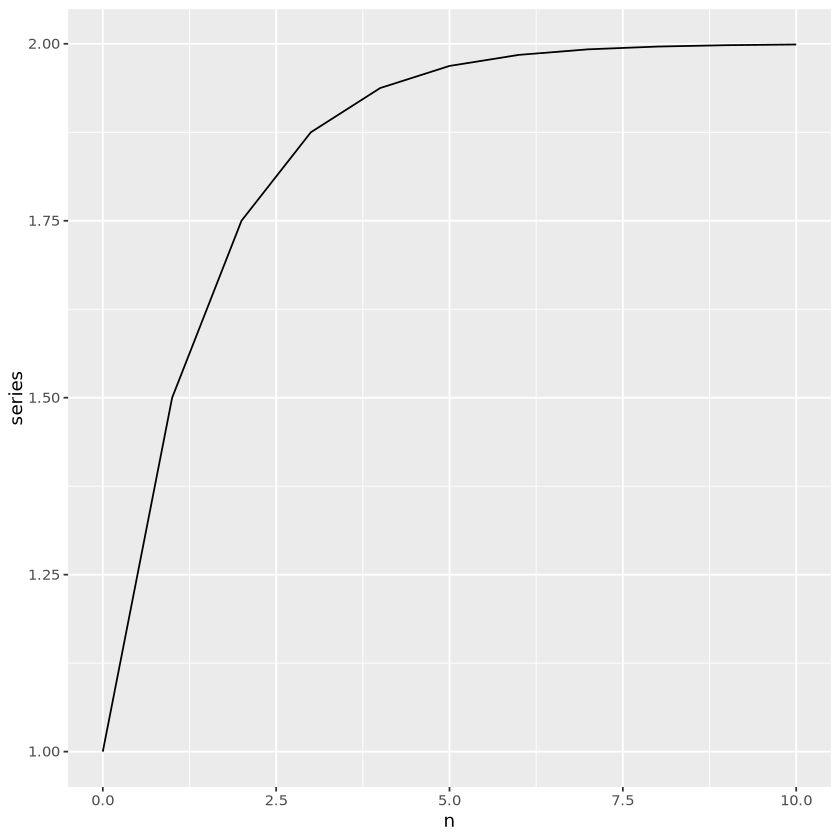

In [ ]:
phi <- 0.5
# This will give you a vector of the first 11 elements

dt_gseries <- tibble(
  n = 0:10,
  el = phi^n,
# The geometric series is simply the cumulative sum of these elements
  series = cumsum(el)
)

dt_gseries |>
  ggplot(aes(x = n, y = series)) + 
  geom_line()


:::

Let us check 




In [ ]:
set.seed(321)

# Set the parameter phi
phi <- 0.5
# Set the initial value (y_{t - 1}) in the above notation
y_init <- 1
# Set the number of periods j
B <- 1

dt <- tibble(
  j = 0:B,
  # Generate random values for e
  e = rnorm(n = B + 1),
  # Add one to the first row of e
  e_trans = e + c(1, rep(0, B)),
  # Add one to all values of e
  e_perm = e + 1,
  # Compute the powers of phi used to weight e/e_trans/e_perm
  phi_powers = phi^(B - j)
)

dt |>
  summarize(
    # The following simply implements the formula for y
    y = phi^(B + 1) * y_init + sum(e * phi_powers),
    y_trans = phi^(B + 1) * y_init + sum(e_trans * phi_powers),
    y_perm = phi^(B + 1) * y_init + sum(e_perm * phi_powers),
    y_diff_trans = y - y_trans,
    y_diff_perm = y - y_perm
  )




|    y| y_trans| y_perm| y_diff_trans| y_diff_perm|
|----:|-------:|------:|------------:|-----------:|
| 0.39|    0.89|   1.89|         -0.5|        -1.5|



:::{#exr-autonomous-solution}

Given a first order difference equation with $\phi = 0.8$, find the
value of the process in $t = 3$, knowing that it started with $y_0 = 5$.
Assume that $e_t = 0$ for all $t$.

:::



In [ ]:
# Type your code here




:::


## First-Order Vector Difference Equations

In this course, we will focus exclusively on univariate time series analysis. Still, for the sake of motivating the study of higher-order linear difference equations, it is convenient to introduce vector linear difference equations.
Let's start with two variables, $x_t$ and $y_t$.

$$
\begin{align}
x_{t} & = \phi_{x,1}x_{t - 1} + \phi_{y, 1}y_{t - 1} + e_{x,t} \\
y_{t} & = \phi_{x,2}x_{t - 1} + \phi_{y, 2}y_{t - 1} + e_{y,t}
\end{align}
$$

It is convenient to write this equation in matrix form.

$$
\underbrace{\begin{pmatrix}
x_{t} \\
y_{t}
\end{pmatrix}}_{\mathbf{z}_t}
= \underbrace{\begin{pmatrix}
\phi_{x, 1} & \phi_{y, 1} \\
\phi_{x, 2} & \phi_{y, 2}
\end{pmatrix} }_{\mathbf{A}}
\underbrace{\begin{pmatrix}
x_{t - 1} \\
y_{t - 1}
\end{pmatrix}}_{\mathbf{z}_{t - 1}} + 
\underbrace{\begin{pmatrix}
e_{x,t} \\
e_{y,t}
\end{pmatrix}}_{\mathbf{e}_t}
$$

$$
\mathbf{z}_{t} = \mathbf{A} \mathbf{z}_{t - 1} + \mathbf{e}_{t}
$$

If $\mathbf{A}$ is a diagonal matrix, then we already know the solution because we can solve each equation separately.

$$
\underbrace{\begin{pmatrix}
x_{t} \\
y_{t}
\end{pmatrix}}_{\mathbf{z}_t}
= \underbrace{\begin{pmatrix}
\phi_{x,1} & 0 \\
0 & \phi_{y, 2}
\end{pmatrix} }_{\mathbf{A}}
\underbrace{\begin{pmatrix}
x_{t - 1} \\
y_{t - 1}
\end{pmatrix}}_{\mathbf{z}_{t - 1}} + 
\underbrace{\begin{pmatrix}
e_{x,t} \\
e_{y,t}
\end{pmatrix}}_{\mathbf{e}_t}
$$



However, $\mathbf{A}$ depends on the subject matter at hand, and we need to be able to handle the general case (not diagonal). Linear algebra
provides an elegant solution to our problem. The eigendecomposition of the matrix $\mathbf{A}$ allows us to transform the system of equations into a form where we can apply the simple solution. After solving the equations, we can back-transform to the original variables.

$$
\mathbf{A} = \mathbf{V}
\begin{pmatrix}
\lambda_1 & 0 \\
0 & \lambda_2
\end{pmatrix}
\mathbf{V}^{-1}
$$

Using this decomposition, we can transform the complicated problem to a simple one with only diagonal entries in the matrix before $\mathbf{z}_{t - 1}$.

$$
\begin{align}
\mathbf{z}_{t} & = \mathbf{A} \mathbf{z}_{t - 1} + \mathbf{e}_{t} \\
\mathbf{z}_{t} & = \mathbf{V} \mathbf{\Lambda}\mathbf{V^{-1}} \mathbf{z}_{t - 1} + \mathbf{e}_{t} \\
\mathbf{V}^{-1} \mathbf{z}_{t} & = \mathbf{V}^{-1} \mathbf{V}\mathbf{\Lambda}\mathbf{V}^{-1} \mathbf{z}_{t - 1} + \mathbf{V}^{-1}\mathbf{e}_{t} \\
\mathbf{V}^{-1} \mathbf{z}_{t} & = \mathbf{\Lambda}\mathbf{V}^{-1} \mathbf{z}_{t - 1} + \mathbf{V}^{-1}\mathbf{e}_{t} \\
\tilde{\mathbf{z}}_{t} & = \mathbf{\Lambda} \tilde{\mathbf{z}}_{t - 1} + \tilde{\mathbf{e}_{t}}
\end{align}
$$

Lets see an example.



In [ ]:
B <- matrix(c(1, 9, 4, 1), ncol = 2)
B


In [ ]:
ed <- eigen(B)
ed


In [ ]:
solve(ed$vectors)


In [ ]:
ed$vectors %*% diag(ed$values) %*% solve(ed$vectors)





In this example the diagonal matrix $\mathbf{\Lambda}$
is equal to

$$
\mathbf{\Lambda} = \begin{pmatrix}
7 & 0 \\
0 & -5
\end{pmatrix}
$$
The inverse of the eigenvectors matrix is 

$$
\mathbf{V}^{-1} = \begin{pmatrix}
0.9 & 0.6 \\
-0.9 & 0.6
\end{pmatrix}
$$

The transformed vectors $\tilde{\mathbf{z}_{t}}$ will look like:

$$
\tilde{\mathbf{z}_{t}} = \mathbf{V}^{-1}\mathbf{z}_t = \begin{pmatrix}
0.9 & 0.6 \\
-0.9 & 0.6
\end{pmatrix}
\begin{pmatrix}
x_{t} \\
y_{t}
\end{pmatrix}
= 
\begin{pmatrix}
0.9x_t + 0.6y_t \\
-0.9x_t + 0.6 y_t
\end{pmatrix}
$$

The whole system looks like:

$$
\begin{pmatrix}
0.9x_t + 0.6y_t \\
-0.9x_t + 0.6 y_t
\end{pmatrix}
=
\begin{pmatrix}
7 & 0 \\
0 & -5
\end{pmatrix}
\begin{pmatrix}
0.9x_{t - 1} + 0.6y_{t - 1} \\
-0.9x_{t - 1} + 0.6 y_{t - 1}
\end{pmatrix}
+ 
\begin{pmatrix}
0.9e_{x,t} + 0.6e_{y,t} \\
-0.9e_{x,t} + 0.6 e_{y,t}
\end{pmatrix}
$$


Now, we can solve the difference equation in the simple case. Once we have found the
solutions, we can transform them back to the original variables $x_t$ and $y_t$.

For the purposes of this course, however, our focus lies on the behavior 
of the system: Does it converge to a stable path?

The answer is in the matrix $\mathbf{A}$. When we start doing the
the recursive substitution that we did in the scalar case, the transformed equations
will look like this:

$$
\begin{align}
\tilde{\mathbf{z}}_{t} & = \mathbf{\Lambda} \tilde{\mathbf{z}}_{t - 1} + \tilde{\mathbf{e}}_{t} \\
\tilde{\mathbf{z}}_{t + 1} & = \mathbf{\Lambda} (\mathbf{\Lambda} \tilde{\mathbf{z}}_{t - 1} + \tilde{\mathbf{e}}_{t}) + \tilde{\mathbf{e}}_{t + 1} \\
\implies \tilde{\mathbf{z}}_{t + 1} & = \mathbf{\Lambda}^2 \tilde{\mathbf{z}}_{t - 1} +\mathbf{\Lambda} \tilde{\mathbf{e}}_{t} + \tilde{\mathbf{e}}_{t + 1}\\
\tilde{\mathbf{z}}_{t + j} & = \mathbf{\Lambda}^{j + 1} \tilde{\mathbf{z}}_{t - 1} + \sum_{k = 0}^{j} \mathbf{\Lambda}^{k} \tilde{\mathbf{e}}_{t + j - k}
\end{align}
$$

You can continue the substitution just like we did in @exr-autonomous-solution. At this
point, you should realize that the system's behavior depends on the matrix $\mathbf{\Lambda}$. If the elements of $\mathbf{\Lambda|$ are less than one in absolute value, the system will return to equilibrium after a shock. Otherwise, it will show explosive behavior. This
leads us to the following problem: How do we find the values of the diagonal matrix? We will make
use of a result from linear algebra.

:::{#thm-eigenvalues}
## Eigenvalues


The eigenvalues of a square matrix $\mathbf{A}$ are the solutions of the following equation.

$$
\det(\mathbf{A} - \lambda\mathbf{I}) = 0
$$
:::


## Second-Order Linear Difference Equations

In a second-order difference equation, the current value $y_t$ depends (directly)
on the values up to two periods before it: $y_{t - 1}$ and $y_{t - 2}$.

$$
y_{t} = \phi_{1}y_{t - 1} + \phi_{2}y_{t - 2} + e_{t}
$$

As in the first-order case, we want to investigate the stability property of this process: How does $y_{t + j}$ change in response to variations in the shocks ($e_t$). It helps to 
express this equation as a first-order VAR process.

$$
\begin{align}
x_{t} & = \phi_{1}x_{t - 1} + \phi_{2}x_{t - 2} + e_{t} \\
x_{t - 1} & = x_{t - 1}
\end{align}
$$

The matrix for the VAR process is simple in this case.

$$
\begin{pmatrix}
x_t \\
x_{t - 1}
\end{pmatrix} = 
\begin{pmatrix}
\phi_1 & \phi_2 \\
1 & 0
\end{pmatrix}
\begin{pmatrix}
x_{t - 1} \\
x_{t - 2}
\end{pmatrix}
+ 
\begin{pmatrix}
e_{t} \\
0
\end{pmatrix}
$$
We can use @thm-eigenvalues to find the eigenvalues of the matrix:

$$
\det(\mathbf{A} - \lambda\mathbf{I}) = 0
$$
In our case of a second-order difference equation, it is simply

$$
\det\begin{pmatrix} 
\phi_1 - \lambda & \phi_2 \\
1 & 0 - \lambda
\end{pmatrix} = 0.
$$

$$
\begin{align}
(\phi_1 - \lambda)(-\lambda) - \phi_2 \cdot 1 = 0 \\
\lambda^2 - \lambda \phi_1 - \phi_2 = 0
\end{align}
$$

The left-hand side of this equation is called the characteristic
polynomial of the difference equation. The whole equation is called the _characteristic_ equation.

Most of the time, we derive this equation using the lag operator:

:::{#def-lag-operator}
## Lag Operator

The lag operator returns the previous (shifted) value of a series.

$$
\begin{align}
& L y_{t} = y_{t - 1}\\
& L^2 y_{t} = L(Ly_t) = L(y_{t - 1}) = y_{t - 2} \\
& L^k y_{t} = y_{t - k}
\end{align}
$$
:::

We can rewrite the difference equation in terms of a polynomial of the lag operator.

$$
\begin{align}
y_{t} = \phi_1 y_{t - 1} + \phi_2 y_{t - 2} + e_t \\
y_{t} = \phi_1 L y_{t} + \phi_2 L^2 y_{t} + e_{t} \\
y_{t}(\underbrace{(1 - \phi_1 L - \phi_2 L^2)}_{\text{Lag Polynomial}}) = e_{t}
\end{align}
$$


The lag polynomial and the characteristic polynomial are related.

$$
\begin{align}
& 1 L^0 - \phi_1 L^1 - \phi_2 L^2 \\
& 1 \lambda^{2 - 0} - \phi_1 \lambda^{2 - 1} - \phi_2 \lambda^{2 - 2} \\
& 1 \lambda^{2} - \phi_1 \lambda^{1} - \phi_2 \lambda^{0} \\
& \lambda^{2} - \phi_1 \lambda - \phi_2 \\
\end{align}
$$

:::{#thm-quadratic-eq}
## Solutions of a Quadratic Equation

The solutions of a quadratic equation 

$$
a \lambda^2 + b \lambda + c = 0
$$

are given by:

$$
\lambda_{1,2} = \frac{-b \pm\sqrt{b^2 - 4ac}}{2a}
$$

$$
(\lambda - \lambda_1)(\lambda - \lambda_2) = 0
$$
:::

In the more general case, you can rely on the Fundamental Theorem of Algebra.

:::{#thm-fundamental-theorem-algebra}
## The Fundamental Theorem of Algebra

Any n-th order polynomial with complex coefficients has exactly n (possibly repeating) complex roots.

$$
a_0 + a_1 \lambda + a_2 \lambda^2 + \ldots a_n\lambda^n = 0 
$$

$$
(\lambda - \lambda_1)(\lambda - \lambda_2)\cdot \ldots\cdot(\lambda - \lambda_n) = 0
$$
:::


:::{#exr-second-order-roots}
## Characteristic roots

Find the characteristic roots of the following difference equation:

$$
y_t = y_{t - 1} + 0.2 y_{t - 2} + e_t
$$
Use @thm-quadratic-eq to compute the roots by hand. First, find the characteristic equation using matrix notation, then use the lag polynomial to derive it. Confirm your solution using
the `polyroot` function in R. Is the equation stable?

:::
:::{.solution}



In [ ]:
# Type your code here




:::

## Further Details: Eigenvalue Decomposition

What is the eigenvalue decomposition of a matrix?

Let us consider what the multiplication of a matrix with a vector actually does. This is easier to understand with two-dimensional vectors, because we can plot them, but the same principle applies to higher dimensions.

Let's define an (arbitrary) matrix $A \in M(2, 2,)$ and a vector $v \in M(2, 1)$, for example:

$$
A = \begin{pmatrix}
-1 & 2.5 \\
-2 & 1.2
\end{pmatrix}
$$

$$
v = \begin{pmatrix}
1 \\
1
\end{pmatrix}
$$


The vector points in the direction of the line $y = x$ (a 45-degree angle) and has length $\sqrt{1^2 + 1^2} = \sqrt{2}$. Let's now multiply the matrix with the vector and see what happens.

$$
A \cdot v = \begin{pmatrix}
-1 & 2.5 \\
-2 & 1.2
\end{pmatrix}
\begin{pmatrix}
1 \\
1
\end{pmatrix}
= 
\begin{pmatrix}
-1 \cdot 1 + 2.5 \cdot 1 \\
-2 \cdot 1 + 1.2 \cdot 1
\end{pmatrix}
=
\begin{pmatrix}
1.5 \\
-0.8
\end{pmatrix}
$$

The result from the multiplication is a new vector of the same dimension as the original vector, but it points in a different direction and as a different length. The matrix $A$ has transformed the vector $v$ into a new vector $v'$. In other words you can think of the matrix as a rule that transforms vectors into new vectors.

Let's compute the new vector in R.



In [ ]:
v = c(1, 1)
A = matrix(c(-1, 2.5, -2, 1.2), ncol = 2, byrow = TRUE)
v1 = A %*% v
v1


In [ ]:
A



Let's now plot the original vector and the new vector and compute their lengths.



In [ ]:
# Create a data frame with the vector coordinates
dt <- tibble(
  x = c(0, 0),
  y = c(0, 0),
  xend = c(1, v1[1]),
  yend = c(1, v1[2])
)

# Plot the vectors
ggplot(dt) +
  geom_segment(aes(x = x, y = y, xend = xend, yend = yend), arrow = arrow(length = unit(0.2, "inches"))) +
  xlim(-3, 2) + ylim(-3, 5) +
  labs(title = "Vector Plot", x = "x", y = "y") +
  theme_minimal()



We have already computed the length of the original vector $v$ (it is $\sqrt{2}$).



In [ ]:
sqrt(2)
sqrt(sum(v^2))



We can apply the same computation to the new vector $v'$.



In [ ]:
sqrt(sum(v1^2))



As we have seen, the matrix A has both rotated the vector and has changed its length.

It turns out that there are special vectors that are not rotated by the matrix. Instead, the matrix multiplication applied to them only changes their length, i.e. the matrix multiplication acts as a simple scalar multiplication.

$$
A v = \lambda v, \quad \lambda \in \mathbb{R}
$$

These are special vectors that exist for square matrices. They are called eigenvectors, and the scalar $\lambda$ is called the eigenvalue. The eigenvectors and eigenvalues of a matrix are the building blocks of the matrix. Any matrix can be decomposed into a product of its eigenvectors and eigenvalues.

How can we find these special vectors and scalars? This is the question that the eigenvalue decomposition answers. 

If the matrix multiplied by the vector should equal the vector multiplied by a scalar, then we can rewrite the equation as:

$$
A v = \lambda v \iff A v - \lambda v = 0 \iff (A - \lambda I) v = 0
$$

where $I$ is the identity matrix (with such a dimenstion that the operations are valid). Note that the zero on the right-hand side is a zero _vector_, not a scalar.

Now there is a simple rule in linear algebra: If the product of a matrix and a vector is zero (and the vector is not the zero vector), then the matrix is singular (i.e. it has no inverse, i.e. it has linearly dependent columns, i.e. its determinant is zero). This means that the matrix $A - \lambda I$ has no inverse, which means that its determinant is zero.

This gives us a way to find the eigenvalues of a matrix:

$$
\det(A - \lambda I) = 0
$$
